# US-005：ICA 伪迹去除

**目标：** 用 ICA 识别并去除眼电、心电等伪迹，获得干净脑电信号。

**关键步骤：** 预处理 → ICA 拟合 → 成分识别 → 去除 → 重建

## 1. ICA 原理速览

ICA (Independent Component Analysis) 假设观测信号是若干独立源的线性混合：
$$ X = A \cdot S $$
- $X$：观测 EEG（通道 × 时间）
- $S$：独立源（成分 × 时间）
- $A$：混合矩阵（通道 × 成分）

ICA 的目标是找到解混矩阵 $W = A^{-1}$，使得 $S = W \cdot X$

**去眼电逻辑：** 找到眼电成分 → 把对应列从 A 中删掉 → 用剩余成分重建信号。

## 2. 准备数据（含滤波预处理）

In [1]:
import mne
import numpy as np
import os
# 目录配置
data_dir = os.path.abspath("./../datasets")
os.makedirs(data_dir, exist_ok=True)
# 每次运行强制更新 config
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)
print("────" * 20)
print("config file =", mne.get_config_path())
print("=" * 80)
# 打印config 内容,友好格式
config = mne.get_config()
for key, value in config.items():
    print(f"* {key:25s}: {value}")
print("────" * 20)

# 加载 sample 数据
sample_dir = mne.datasets.sample.data_path()
raw_fname = sample_dir / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_fname, preload=True)

# 保留 EEG + EOG 通道（EOG 用于帮助识别眼电成分）
raw.pick_types(eeg=True, eog=True)
print(f"通道: {raw.ch_names}")

# 预处理：1Hz 高通（ICA 要求去掉慢漂移）
raw.filter(l_freq=1.0, h_freq=None)
print(f"高通滤波: {raw.info['highpass']} Hz")

────────────────────────────────────────────────────────────────────────────────
config file = /Users/usst_ziyi/.mne/mne-python.json
* MNE_BROWSE_RAW_SIZE      : 14.277777777777779,11.597222222222221
* MNE_DATA                 : /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/datasets
* MNE_DATASETS_SAMPLE_PATH : /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/datasets
* MNE_PATH                 : ./datasets
────────────────────────────────────────────────────────────────────────────────
Opening raw data file /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/datasets/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick

In [2]:
# 选择 EEG 通道
eeg_picks: list = mne.pick_types(raw.info, eeg=True, eog=False)
print(eeg_picks)
print(raw.info.get('ch_names'))


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58]
['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 011', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016', 'EEG 017', 'EEG 018', 'EEG 019', 'EEG 020', 'EEG 021', 'EEG 022', 'EEG 023', 'EEG 024', 'EEG 025', 'EEG 026', 'EEG 027', 'EEG 028', 'EEG 029', 'EEG 030', 'EEG 031', 'EEG 032', 'EEG 033', 'EEG 034', 'EEG 035', 'EEG 036', 'EEG 037', 'EEG 038', 'EEG 039', 'EEG 040', 'EEG 041', 'EEG 042', 'EEG 043', 'EEG 044', 'EEG 045', 'EEG 046', 'EEG 047', 'EEG 048', 'EEG 049', 'EEG 050', 'EEG 051', 'EEG 052', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060', 'EOG 061']


## 3. 拟合 ICA

**重要：** ICA 前必须做高通滤波（≥1 Hz），否则慢漂移会占据独立成分。

In [3]:
from mne.preprocessing import ICA

# 设置随机种子保证可复现
ica = ICA(
    n_components=20,        # 选择 20 个成分
    method='fastica',       # FastICA 算法（最常用）
    random_state=42,
    max_iter='auto',
)

# 拟合（只对 EEG 通道做 ICA，排除 EOG）
eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False)
ica.fit(raw, picks=eeg_picks)
print(ica)

Fitting ICA to data using 59 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 2.0s.
<ICA | raw data decomposition, method: fastica (fit in 49 iterations on 166800 samples), 20 ICA components (59 PCA components available), channel types: eeg, no sources marked for exclusion>


## 4. 识别眼电成分

### 方法一：看地形图（Topomap）
眼电成分的地形图特征：能量集中在前额，左右对称分布。

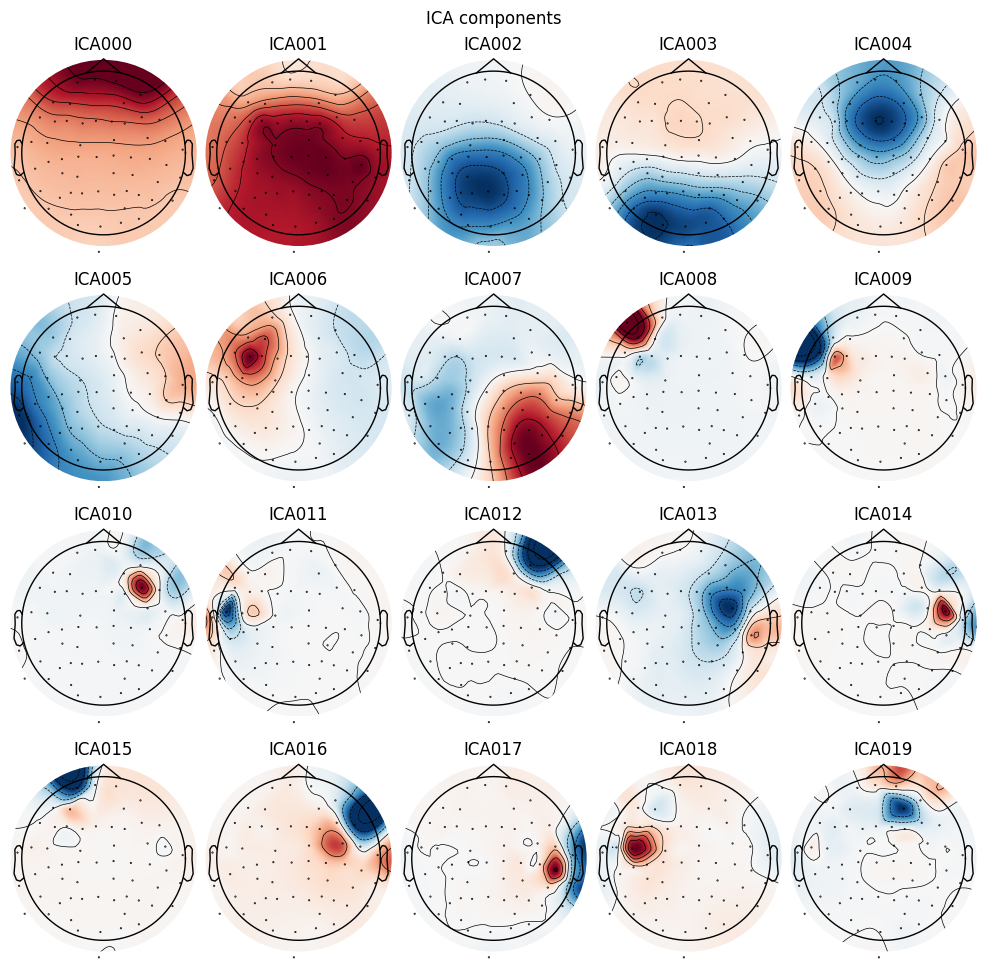

In [4]:
# 绘制所有成分的地形图
ica_fig = ica.plot_components()

### 方法二：看时序图
眼电成分的时序特征：突发性大幅跳变（眨眼）。

In [88]:
# 绘制成分时序图（可以缩放查看）
i = ica.plot_sources(raw)

Creating RawArray with float64 data, n_channels=21, n_times=166800
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


### 方法三：自动检测（用 EOG 通道相关性）
最省事的方式——让 MNE 自动找出和 EOG 通道高相关的成分。

In [4]:
# 自动找到与 EOG 通道相关的成分
# eog_indices: 眼电成分索引
# eog_scores: 相关性得分，不是z-score
# 返回的是皮尔逊相关系数：-1到1之间，0表示不相关，1表示完全相关
# 负相关表示眼电通道与EEG通道负相关，正相关表示正相关
eog_indices, eog_scores = ica.find_bads_eog(
    raw, ch_name='EOG 061',  # sample 数据的 EOG 通道名，实际换成你的 EOG 通道
    threshold=3.0            # Z-score 阈值
)
print(f"眼电成分索引: {eog_indices}")
print(f"得分: {eog_scores[:]}")

Using EOG channel: EOG 061
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 6007 samples (10.001 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz

### 方法四：手动指定（凭经验判断）
看完地形图和时序图后，手动标记眼电成分。

In [9]:
# 假设第 0、1 个成分是眼电
ica.exclude = [0]
print(f"已排除成分: {ica.exclude}")
# ica_fig = ica.plot_components()

已排除成分: [0]


## 5. 应用 ICA 去除伪迹

`ica.apply()` 从原始信号中减去被排除的成分。

In [ ]:
# 使用自动检测的结果
ica.exclude = eog_indices[:2] if len(eog_indices) >= 2 else eog_indices
print(ica.exclude)


# 应用到数据（副本）
raw_clean = raw.copy()
ica.apply(raw_clean) # 只能执行一次

print(f"ICA 应用完成，排除了 {len(ica.exclude)} 个成分")

[np.int64(0)]
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 1 ICA component
    Projecting back using 59 PCA components
ICA 应用完成，排除了 1 个成分


## 6. 对比 ICA 前后

肉眼检查去眼电效果。

In [ ]:
# 选择一段含眨眼的区间对比
# 交互式对比
%matplotlib qt
raw.plot(duration=1, n_channels=10, scalings='auto')
raw_clean.plot(duration=1, n_channels=10, scalings='auto')

print("ICA 前后对比：取消上方注释查看交互式波形。")

## 7. 保存 ICA 解

ICA 拟合很耗时，建议保存下来以后复用。

In [9]:
# 保存 ICA 解
ica.save('solution-ica.fif')
print("ICA 解已保存: solution-ica.fif")

# 也保存处理后的数据
# raw_clean.save('eeg_ica_cleaned.fif', overwrite=True)
print("也建议保存处理后的 raw_clean")

Writing ICA solution to /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/notebooks/solution-ica.fif...
ICA 解已保存: solution-ica.fif
也建议保存处理后的 raw_clean


## 8. 应用 ICA 解到数据

In [10]:
from mne.preprocessing import read_ica

# 1. 读取 ICA 对象
# 这一步会从文件中加载 ICA 的权重矩阵和分解结果
ica_loaded = read_ica('solution-ica.fif')

print("ICA 对象已读取！")
print(f"ICA 方法: {ica_loaded.method}") # 确认是 infomax 还是 fastica
print(f"排除列表: {ica_loaded.exclude}") # 确认之前标记的坏成分还在不在

# -----------------------------------------------------------
# 2. (可选但推荐) 将 ICA 挂载回原始数据
# 如果你要查看成分或应用剔除，需要结合 raw 数据
# -----------------------------------------------------------

# 假设你已经重新加载了原始数据 (raw)
# raw = mne.io.read_raw_fif('your_original_data.fif', preload=True)

# 将读取的 ICA 对象与 raw 数据关联起来
# ica_loaded.apply(raw) 

# 现在你可以像之前一样操作了，例如：
# ica_loaded.plot_components() 
# clean_raw = ica_loaded.apply(raw)

Reading /Users/usst_ziyi/Programs/QwenPaw/projects/EEG/mne-eeg-learning/notebooks/solution-ica.fif ...
Now restoring ICA solution ...
Ready.
ICA 对象已读取！
ICA 方法: fastica
排除列表: [np.int32(0)]


## 9. ICA 参数的调优

| 参数 | 含义 | 建议 |
|------|------|------|
| `n_components` | 要分解的成分数 | 通常设为通道数的 80%-100%，或 20-30 |
| `method` | ICA 算法 | 'fastica'（默认/最稳）、'picard'（更快）、'infomax' |
| `random_state` | 随机种子 | 固定值保证可复现 |
| `max_iter` | 最大迭代次数 | 'auto' 通常够，不收敛时加大 |

## 10. 其他伪迹

### 心电 (ECG) 伪迹
```python
ecg_indices, ecg_scores = ica.find_bads_ecg(raw, ch_name='ECG001')
```

### 肌电 (EMG) 伪迹
没有自动化方法，靠地形图（局部、高频分布）和频谱（>20 Hz 功率高）手动判断。

## 11. 练习

1. 对比 `n_components=10` 和 `n_components=30` 的地形图差异
2. 尝试用 `method='picard'`，对比和 FastICA 的速度和结果
3. 手选 ICA 成分 vs 自动检测，看看区别在哪里

## 12. 钟形图
如果我们同时掷 2 个骰子，把点数加起来，结果会怎样？
答案是：一个钟形图。

理论概率: [0.02777778 0.05555556 0.08333333 0.11111111 0.13888889 0.16666667
 0.13888889 0.11111111 0.08333333 0.05555556 0.02777778]
理论概率: ['0.028', '0.056', '0.083', '0.111', '0.139', '0.167', '0.139', '0.111', '0.083', '0.056', '0.028']
实验概率: [0.03  0.06  0.079 0.107 0.144 0.174 0.132 0.112 0.083 0.058 0.021]


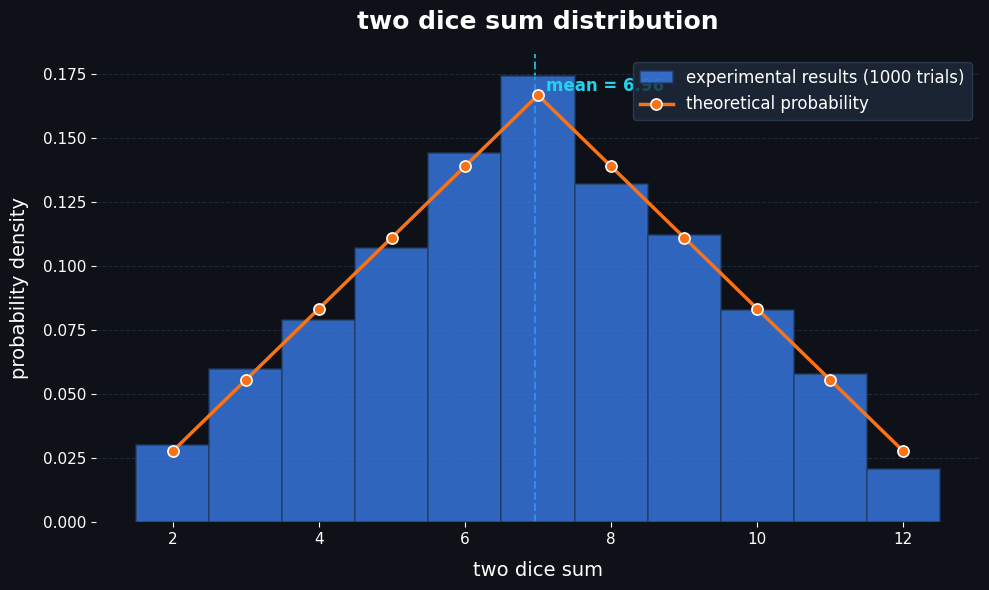

  实验次数 : 1000
  样本均值 : 6.96  (理论值 7.00)
  样本标准差: 2.40  (理论值 2.42)


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ── 模拟参数 ──
np.random.seed(42)
n_experiments = 1000

# ── 模拟掷骰子 ──
die1 = np.random.randint(1, 7, size=n_experiments)
die2 = np.random.randint(1, 7, size=n_experiments)
totals = die1 + die2 # 两个骰子点数之和

# 2=1+1
# 3=1+2,2+1
# 4=1+3,2+2,3+1
# 5=1+4,2+3,3+2,4+1
# 6=1+5,2+4,3+3,4+2,5+1
# 7=1+6,2+5,3+4,4+3,5+2,6+1
# 8=2+6,3+5,4+4,5+3,6+2
# 9=3+6,4+5,5+4,6+3
# 10=4+6,5+5,6+4
# 11=5+6,6+5
# 12=6+6
theoretical = np.array([1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1], dtype=float)
theoretical /= theoretical.sum() # 理论概率
print(f"理论概率: {theoretical}")


x_theory = np.arange(2, 13)

# ── 绘图 ──
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# 直方图（实验结果）
bins = np.arange(1.5, 13.5, 1)

# 根据totals绘制直方图,返回直方图的bin高度、bin中心、patch对象
counts, b, patches = ax.hist(
    totals, bins=bins, density=True,
    color="#3b82f6", edgecolor="#1e3a5f", linewidth=1.2,
    alpha=0.75, label=f"experimental results ({n_experiments} trials)",
    zorder=3
)
print(f"理论概率: {[f'{p:.3f}' for p in theoretical]}")
print(f"实验概率: {counts}")



# 叠加理论曲线
ax.plot(
    x_theory, theoretical,
    color="#f97316", marker="o", markersize=8,
    linewidth=2.5, markeredgecolor="white", markeredgewidth=1.2,
    label="theoretical probability", zorder=4
)

# ── 样式 ──
ax.set_xlabel("two dice sum", fontsize=14, color="white", labelpad=10)
ax.set_ylabel("probability density", fontsize=14, color="white", labelpad=10)
ax.set_title(
    "two dice sum distribution",
    fontsize=18, color="white", fontweight="bold", pad=18,
)

ax.set_xticks(x_theory)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(colors="white", labelsize=11)
ax.spines[:].set_visible(False)
ax.grid(axis="y", color="#1e293b", linewidth=0.8, linestyle="--")
ax.legend(
    fontsize=12, facecolor="#1e293b", edgecolor="#334155",
    labelcolor="white", loc="upper right",
)


# 标注均值
mean_val = np.mean(totals)
ax.axvline(mean_val, color="#22d3ee", linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(
    mean_val + 0.15, ax.get_ylim()[1] * 0.92,
    f"mean = {mean_val:.2f}",
    fontsize=12, color="#22d3ee", fontweight="bold",
)

plt.tight_layout()
# plt.savefig("dice_simulation.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

# ── 打印统计摘要 ──
print("=" * 40)
print(f"  实验次数 : {n_experiments}")
print(f"  样本均值 : {mean_val:.2f}  (理论值 7.00)")
print(f"  样本标准差: {np.std(totals):.2f}  (理论值 2.42)")
print("=" * 40)


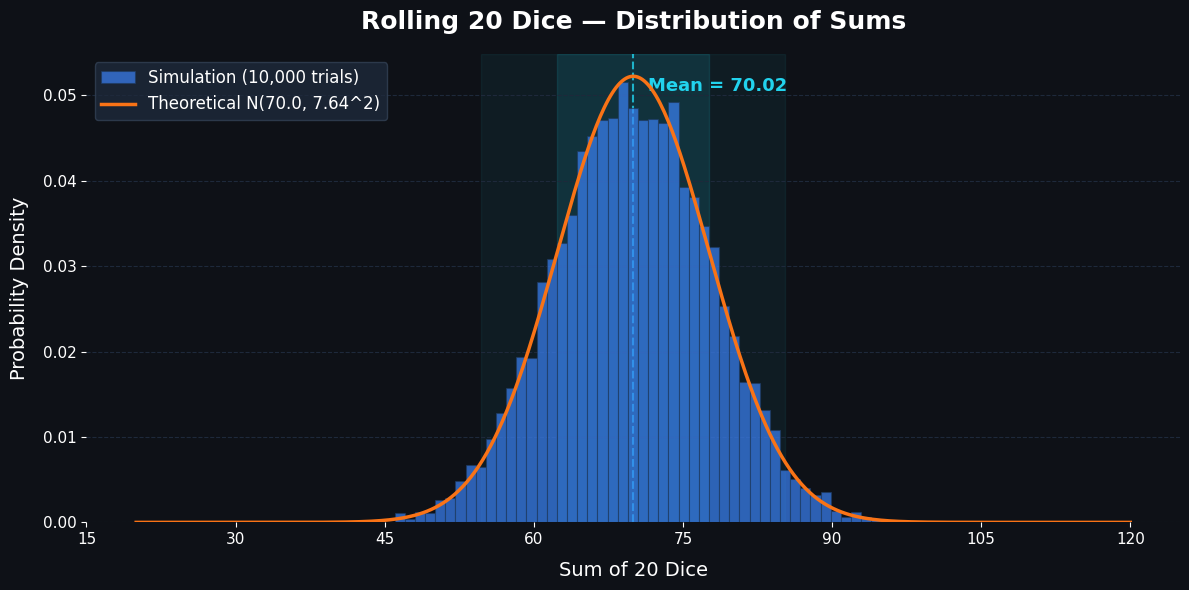

  Dice count     : 20
  Trials         : 10,000
  Sample mean    : 70.02  (theoretical 70.0)
  Sample std dev : 7.65  (theoretical 7.64)
  Range          : 46 ~ 97


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ── 模拟参数 ──
np.random.seed(42)
n_dice = 20
n_experiments = 10000

# ── 模拟掷骰子 ──
rolls = np.random.randint(1, 7, size=(n_experiments, n_dice))
totals = rolls.sum(axis=1)

# ── 理论正态分布（中心极限定理）──
mu = n_dice * 3.5
sigma = np.sqrt(n_dice * 35 / 12)
x_norm = np.linspace(n_dice, n_dice * 6, 500)
y_norm = (1 / (sigma * np.sqrt(2 * np.pi))) * \
         np.exp(-0.5 * ((x_norm - mu) / sigma) ** 2)

# ── 绘图 ──
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# 直方图
ax.hist(
    totals, bins=50, density=True,
    color="#3b82f6", edgecolor="#1e3a5f", linewidth=0.8,
    alpha=0.7, label=f"Simulation ({n_experiments:,} trials)",
    zorder=3,
)

# 叠加理论正态曲线
ax.plot(
    x_norm, y_norm,
    color="#f97316", linewidth=2.5,
    label=f"Theoretical N({mu}, {sigma:.2f}^2)",
    zorder=4,
)

# 均值竖线
ax.axvline(mu, color="#22d3ee", linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(
    mu + 1.5, ax.get_ylim()[1] * 0.92,
    f"Mean = {np.mean(totals):.2f}",
    fontsize=13, color="#22d3ee", fontweight="bold",
)

# ±1σ / ±2σ 区域
for i, alpha_fill in [(1, 0.12), (2, 0.06)]:
    ax.axvspan(mu - i * sigma, mu + i * sigma,
               color="#22d3ee", alpha=alpha_fill, zorder=1)

# ── 样式 ──
ax.set_xlabel(f"Sum of {n_dice} Dice", fontsize=14, color="white", labelpad=10)
ax.set_ylabel("Probability Density", fontsize=14, color="white", labelpad=10)
ax.set_title(
    f"Rolling {n_dice} Dice — Distribution of Sums",
    fontsize=18, color="white", fontweight="bold", pad=18,
)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(colors="white", labelsize=11)
ax.spines[:].set_visible(False)
ax.grid(axis="y", color="#1e293b", linewidth=0.8, linestyle="--")
ax.legend(
    fontsize=12, facecolor="#1e293b", edgecolor="#334155",
    labelcolor="white", loc="upper left",
)

plt.tight_layout()
# plt.savefig("dice_20_simulation.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

# ── 打印统计摘要 ──
print("=" * 45)
print(f"  Dice count     : {n_dice}")
print(f"  Trials         : {n_experiments:,}")
print(f"  Sample mean    : {np.mean(totals):.2f}  (theoretical {mu})")
print(f"  Sample std dev : {np.std(totals):.2f}  (theoretical {sigma:.2f})")
print(f"  Range          : {totals.min()} ~ {totals.max()}")
print("=" * 45)
